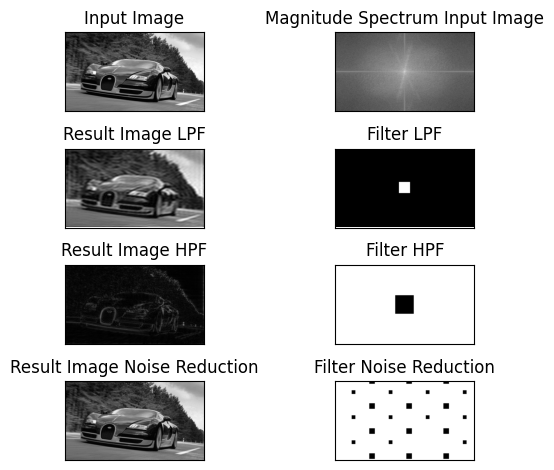

In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

# Membaca gambar dalam mode grayscale
img = cv2.imread('mobil.jpg', 0)

# Konversi ke float32 dan lakukan DFT
img_float32 = np.float32(img)
dft = cv2.dft(img_float32, flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

rows, cols = img.shape
crow, ccol = int(rows/2), int(cols/2) # Titik tengah

# --- 1. MEMBUAT MASK FILTER ---

# Low Pass Filter (LPF) Mask
mask_lpf = np.zeros((rows, cols, 2), np.uint8)
mask_lpf[crow-30:crow+30, ccol-30:ccol+30] = 1

# High Pass Filter (HPF) Mask
mask_hpf = np.ones((rows, cols, 2), np.uint8)
mask_hpf[crow-50:crow+50, ccol-50:ccol+50] = 0

# Custom Noise Reduction Mask
mask_red = np.ones((rows, cols, 2), np.uint8)

for i in range(60, rows, 135):
    for j in range(100, cols, 200):
        if not (i == 330 and j == 500):
            mask_red[i-10:i+10, j-10:j+10] = 0

for i in range(0, rows, 135):
    for j in range(200, cols, 200):
        if not (i == 330 and j == 500):
            mask_red[max(0, i-15):min(rows, i+15), max(0, j-15):min(cols, j+15)] = 0

# --- 2. PROSES FILTERING (INVERSE DFT) ---

def apply_mask_and_idft(dft_data, mask):
    fshift = dft_data * mask
    f_ishift = np.fft.ifftshift(fshift)
    img_back = cv2.idft(f_ishift)
    img_back = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])
    return img_back

img_back_lpf = apply_mask_and_idft(dft_shift, mask_lpf)
img_back_hpf = apply_mask_and_idft(dft_shift, mask_hpf)
img_back_red = apply_mask_and_idft(dft_shift, mask_red)

# Normalisasi hasil untuk tampilan cv2.imshow
l_out_lpf = cv2.normalize(img_back_lpf, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
l_out_hpf = cv2.normalize(img_back_hpf, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
l_out_red = cv2.normalize(img_back_red, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

# --- 3. VISUALISASI ---

# Magnitude Spectrum untuk input
magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]))

plt.subplot(421), plt.imshow(img, cmap='gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])

plt.subplot(422), plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum Input Image'), plt.xticks([]), plt.yticks([])

plt.subplot(423), plt.imshow(img_back_lpf, cmap='gray')
plt.title('Result Image LPF'), plt.xticks([]), plt.yticks([])

plt.subplot(424), plt.imshow(mask_lpf[:, :, 0], cmap='gray')
plt.title('Filter LPF'), plt.xticks([]), plt.yticks([])

plt.subplot(425), plt.imshow(img_back_hpf, cmap='gray')
plt.title('Result Image HPF'), plt.xticks([]), plt.yticks([])

plt.subplot(426), plt.imshow(mask_hpf[:, :, 0], cmap='gray')
plt.title('Filter HPF'), plt.xticks([]), plt.yticks([])

plt.subplot(427), plt.imshow(img_back_red, cmap='gray')
plt.title('Result Image Noise Reduction'), plt.xticks([]), plt.yticks([])

plt.subplot(428), plt.imshow(mask_red[:, :, 0], cmap='gray')
plt.title('Filter Noise Reduction'), plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

# Tampilan menggunakan OpenCV
cv2.imshow('Result Image Filter LPF', l_out_lpf)
cv2.imshow('Result Image Filter HPF', l_out_hpf)
cv2.imshow('Result Image Noise Reduction', l_out_red)
cv2.imshow('Input Image', img)

cv2.waitKey(0)
cv2.destroyAllWindows()